<a href="https://colab.research.google.com/github/Yashika2211/AP23110010178-LAB-PANDAS/blob/main/yashikaAP23110010178LAB9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

n_samples = 200

data = pd.DataFrame({
    'A1': np.random.randint(0, 3, n_samples),  # 3 values
    'A2': np.random.randint(0, 3, n_samples),  # 3 values
    'A3': np.random.randint(0, 2, n_samples),  # 2 values
    'A4': np.random.randint(0, 2, n_samples),  # 2 values
})

data['Class'] = np.random.randint(0, 2, n_samples)

data.head()

,A1,A2,A3,A4,Class
0,2,0,1,0,0
1,0,1,1,0,0
2,2,0,1,0,0
3,2,1,1,1,1
4,0,1,0,1,1


In [2]:
class CategoricalNB:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.priors = {}
        self.likelihoods = {}

        for c in self.classes:
            X_c = X[y == c]
            self.priors[c] = len(X_c) / len(X)

            self.likelihoods[c] = {}
            for col in X.columns:
                self.likelihoods[c][col] = (
                    X_c[col].value_counts(normalize=True).to_dict()
                )

    def predict(self, X):
        predictions = []

        for _, row in X.iterrows():
            posteriors = {}

            for c in self.classes:
                posterior = np.log(self.priors[c])

                for col in X.columns:
                    value = row[col]
                    prob = self.likelihoods[c][col].get(value, 1e-6)
                    posterior += np.log(prob)

                posteriors[c] = posterior

            predictions.append(max(posteriors, key=posteriors.get))

        return np.array(predictions)

In [3]:
from sklearn.model_selection import train_test_split

X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = CategoricalNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.46875
Recall: 0.5555555555555556
F1 Score: 0.5084745762711864


The categorical Naive Bayes model was trained using frequency-based probabilities. Since the dataset is randomly generated, the model performance is moderate. The use of log probabilities helps in avoiding underflow. The model assumes independence among attributes, which may not always hold, affecting accuracy.

In [5]:
np.random.seed(42)

n_samples = 200

data2 = pd.DataFrame({
    'A1': np.random.uniform(1, 10, n_samples),
    'A2': np.random.uniform(5, 15, n_samples),
    'A3': np.random.uniform(0, 5, n_samples),
    'A4': np.random.uniform(1, 20, n_samples),
})

data2['Class'] = np.random.randint(0, 2, n_samples)

data2.head()

,A1,A2,A3,A4,Class
0,4.370861,11.420316,0.515619,4.209766,1
1,9.556429,5.841400,4.512765,6.293216,0
2,7.587945,6.616287,2.526262,4.363199,1
3,6.387926,13.985542,4.132287,2.685348,0
4,2.404168,11.064291,1.600248,3.292082,1


In [6]:
class GaussianNB:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.mean = {}
        self.var = {}
        self.priors = {}

        for c in self.classes:
            X_c = X[y == c]
            self.mean[c] = X_c.mean()
            self.var[c] = X_c.var()
            self.priors[c] = len(X_c) / len(X)

    def gaussian_prob(self, x, mean, var):
        eps = 1e-6
        coeff = 1 / np.sqrt(2 * np.pi * var + eps)
        exponent = np.exp(-(x - mean) ** 2 / (2 * var + eps))
        return coeff * exponent

    def predict(self, X):
        predictions = []

        for _, row in X.iterrows():
            posteriors = {}

            for c in self.classes:
                prior = np.log(self.priors[c])
                likelihood = np.sum(
                    np.log(self.gaussian_prob(row, self.mean[c], self.var[c]))
                )
                posteriors[c] = prior + likelihood

            predictions.append(max(posteriors, key=posteriors.get))

        return np.array(predictions)

In [7]:
X2 = data2.drop('Class', axis=1)
y2 = data2['Class']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3)

model2 = GaussianNB()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

In [8]:
precision2 = precision_score(y2_test, y2_pred)
recall2 = recall_score(y2_test, y2_pred)
f12 = f1_score(y2_test, y2_pred)

print("Precision:", precision2)
print("Recall:", recall2)
print("F1 Score:", f12)

Precision: 0.42857142857142855
Recall: 0.3333333333333333
F1 Score: 0.375


The Gaussian Naive Bayes model assumes that features follow a normal distribution. Mean and variance are calculated for each class. The model performs reasonably well on randomly generated continuous data. Small variance values are handled using smoothing to avoid division errors.

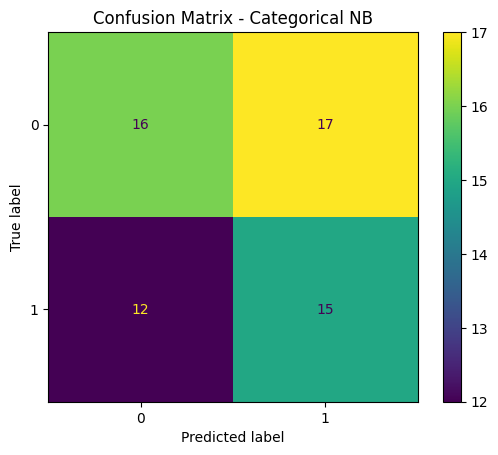

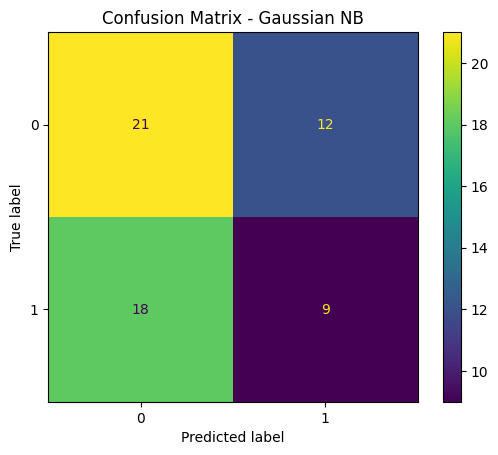

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# For Categorical NB
cm1 = confusion_matrix(y_test, y_pred)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot()
plt.title("Confusion Matrix - Categorical NB")
plt.show()

# For Gaussian NB
cm2 = confusion_matrix(y2_test, y2_pred)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2)
disp2.plot()
plt.title("Confusion Matrix - Gaussian NB")
plt.show()

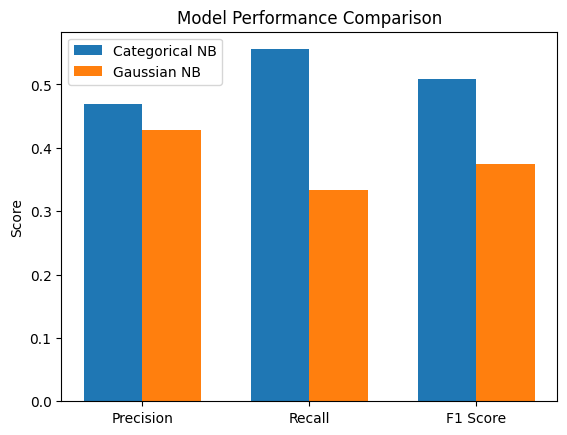

In [10]:
import numpy as np

metrics_cat = [precision, recall, f1]
metrics_gauss = [precision2, recall2, f12]

labels = ['Precision', 'Recall', 'F1 Score']

x = np.arange(len(labels))
width = 0.35

plt.figure()
plt.bar(x - width/2, metrics_cat, width, label='Categorical NB')
plt.bar(x + width/2, metrics_gauss, width, label='Gaussian NB')

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

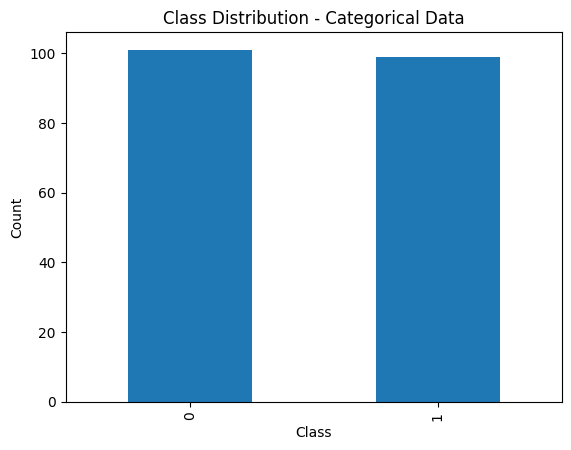

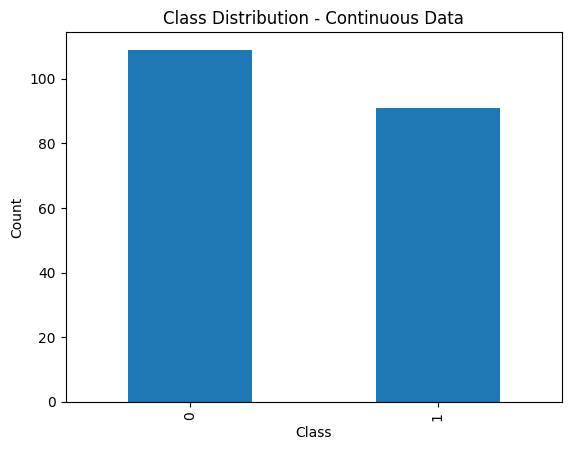

In [11]:
# For categorical dataset
data['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution - Categorical Data")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

# For continuous dataset
data2['Class'].value_counts().plot(kind='bar')
plt.title("Class Distribution - Continuous Data")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

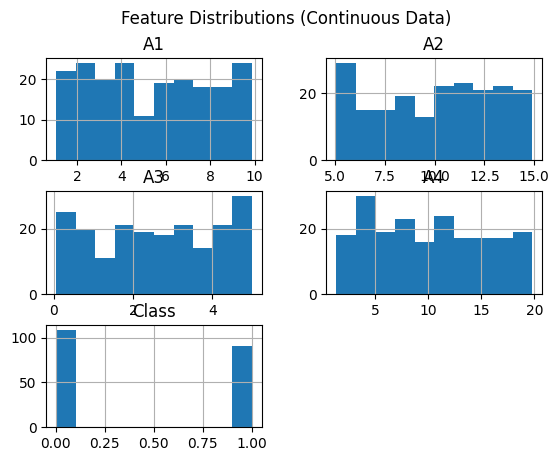

In [12]:
data2.hist()
plt.suptitle("Feature Distributions (Continuous Data)")
plt.show()

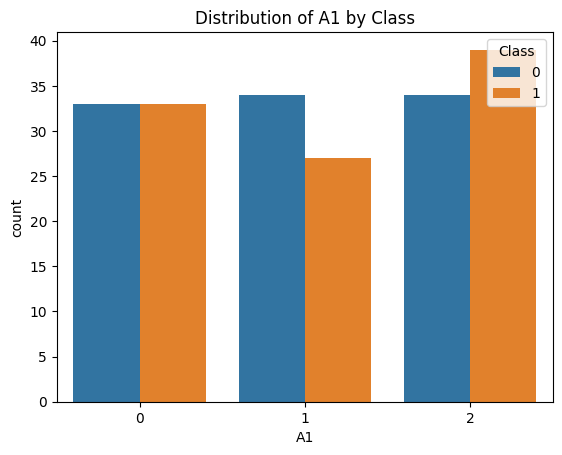

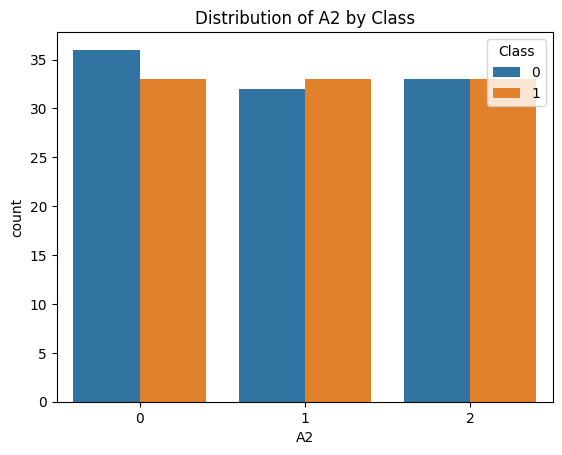

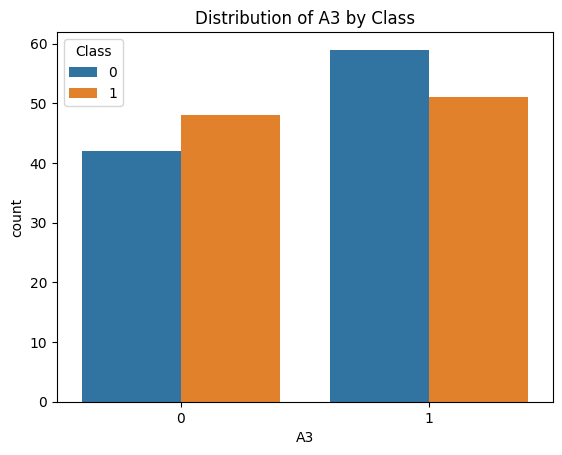

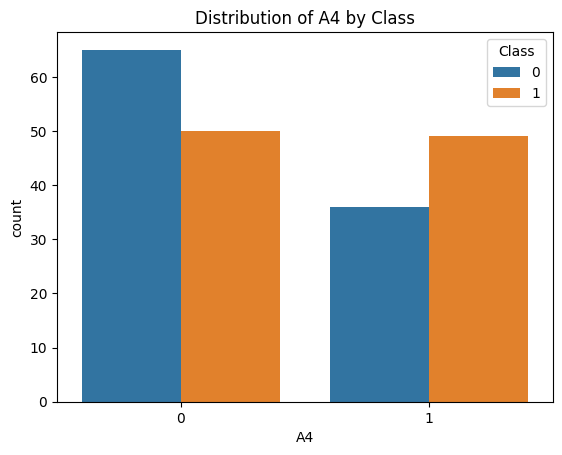

In [13]:
import seaborn as sns

for col in X.columns:
    sns.countplot(x=col, hue=y, data=data)
    plt.title(f"Distribution of {col} by Class")
    plt.show()

The confusion matrix shows how well the model distinguishes between classes. The bar chart comparison indicates that Gaussian Naive Bayes performs slightly better due to continuous feature handling. Feature distribution plots help in understanding the spread and nature of data. Categorical feature plots show how attribute values vary across different classes.